# Data Loading and Exploratory Data Analysis

**Objective:** Load the augmented smart grid stability dataset, verify its integrity, log the
software environment, and perform a systematic exploratory data analysis (EDA) on the raw
12 input features and the binary target variable `stabf`.

**Inputs:**
- `../data/smart_grid_stability_augmented.csv`

**Outputs:**
- `../results/tables/environment.json` — hardware and software environment record
- `../results/tables/dataset_summary.csv` — descriptive statistics
- `../results/figures/class_distribution.png / .pdf`
- `../results/figures/feature_histograms.png / .pdf`
- `../results/figures/feature_distribution_by_class.png / .pdf`
- `../results/figures/violin_plots.png / .pdf`
- `../results/figures/correlation_matrix.png / .pdf`

**Note on the `stab` column:** The continuous stability index `stab` is the numerical
counterpart of the binary target `stabf`. It is excluded from all feature sets throughout
the pipeline to prevent data leakage.

In [ ]:
import os
import sys
import json
import platform
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings('ignore')

# ── Add project root to path & import shared plot config ──────────────────
sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import (
    apply_plot_style, CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED,
    PALETTE_2, CLASS_PALETTE
)

# ── Configuration ──────────────────────────────────────────────────────────
RANDOM_STATE   = 42
FIGURE_DPI     = 300
TARGET         = 'stabf'
LEAKAGE_COL    = 'stab'

DATA_DIR       = '../data'
RESULTS_TABLES = '../results/tables'
RESULTS_FIGS   = '../results/figures'

os.makedirs(RESULTS_TABLES, exist_ok=True)
os.makedirs(RESULTS_FIGS,   exist_ok=True)

# ── Journal-quality figure defaults ────────────────────────────────────────
apply_plot_style()

# ── Environment record ─────────────────────────────────────────────────────
env = {
    'recorded_at'    : datetime.datetime.now().isoformat(),
    'platform'       : platform.platform(),
    'processor'      : platform.processor(),
    'python_version' : sys.version,
    'numpy_version'  : np.__version__,
    'pandas_version' : pd.__version__,
    'matplotlib_version': matplotlib.__version__,
    'seaborn_version': sns.__version__,
    'sklearn_version': sklearn.__version__,
}

# Add memory info if psutil is available
try:
    import psutil
    mem = psutil.virtual_memory()
    env['total_ram_gb'] = round(mem.total / (1024 ** 3), 2)
    env['cpu_count_logical'] = psutil.cpu_count(logical=True)
    env['cpu_count_physical'] = psutil.cpu_count(logical=False)
except ImportError:
    pass

with open(os.path.join(RESULTS_TABLES, 'environment.json'), 'w') as f:
    json.dump(env, f, indent=2)

print("Environment logged:")
for k, v in env.items():
    print(f"  {k}: {v}")

Environment logged:
  recorded_at: 2026-03-14T06:04:54.708067
  platform: Windows-11-10.0.26200-SP0
  processor: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
  python_version: 3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:14) [MSC v.1929 64 bit (AMD64)]
  numpy_version: 2.2.5
  pandas_version: 2.2.3
  matplotlib_version: 3.10.5
  seaborn_version: 0.13.2
  sklearn_version: 1.7.1
  total_ram_gb: 15.73
  cpu_count_logical: 8
  cpu_count_physical: 4


## 1. Data Loading

The augmented dataset is sourced from the UCI Machine Learning Repository (ID 471) and is
publicly available on Kaggle at:
https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability

It contains 60,000 samples generated from a simulation of a four-node star network topology
under varying producer/consumer configurations. Each sample has 12 input features and one
binary target variable (`stabf`: stable / unstable).

In [2]:
file_path = os.path.join(DATA_DIR, 'smart_grid_stability_augmented.csv')
df = pd.read_csv(file_path)

# Integrity checks
n_missing    = df.isnull().sum().sum()
n_duplicates = df.duplicated().sum()

print(f"Shape         : {df.shape}")
print(f"Missing values: {n_missing}")
print(f"Duplicates    : {n_duplicates}")
print()
print(df.dtypes)
df.head()


Shape         : (60000, 14)
Missing values: 0
Duplicates    : 0

tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## 2. Dataset Summary Statistics

Descriptive statistics for all 12 input features. The `stab` column is excluded here
because it is a direct numerical encoding of the target and would constitute data leakage
if used as a feature.

In [3]:
feature_cols = [c for c in df.columns if c not in [TARGET, LEAKAGE_COL]]

summary = df[feature_cols].describe().T
summary['range'] = summary['max'] - summary['min']
summary.to_csv(os.path.join(RESULTS_TABLES, 'dataset_summary.csv'))
print(summary.round(4).to_string())


        count   mean     std     min     25%    50%     75%     max   range
tau1  60000.0  5.250  2.7424  0.5008  2.8749  5.250  7.6247  9.9995  9.4987
tau2  60000.0  5.250  2.7424  0.5001  2.8750  5.250  7.6249  9.9998  9.4997
tau3  60000.0  5.250  2.7424  0.5001  2.8750  5.250  7.6249  9.9998  9.4997
tau4  60000.0  5.250  2.7424  0.5001  2.8750  5.250  7.6249  9.9998  9.4997
p1    60000.0  3.750  0.7521  1.5826  3.2183  3.751  4.2824  5.8644  4.2818
p2    60000.0 -1.250  0.4330 -1.9999 -1.6250 -1.250 -0.8750 -0.5000  1.4999
p3    60000.0 -1.250  0.4330 -1.9999 -1.6250 -1.250 -0.8750 -0.5000  1.4999
p4    60000.0 -1.250  0.4330 -1.9999 -1.6250 -1.250 -0.8750 -0.5000  1.4999
g1    60000.0  0.525  0.2742  0.0500  0.2875  0.525  0.7624  0.9999  0.9499
g2    60000.0  0.525  0.2742  0.0500  0.2875  0.525  0.7625  1.0000  0.9500
g3    60000.0  0.525  0.2742  0.0500  0.2875  0.525  0.7625  1.0000  0.9500
g4    60000.0  0.525  0.2742  0.0500  0.2875  0.525  0.7625  1.0000  0.9500


## 3. Class Distribution

The dataset has a mild class imbalance: approximately 63.8% unstable and 36.2% stable.
This imbalance is moderate and does not require resampling; all models in this study are
evaluated without any class balancing technique. The imbalance is accounted for through
stratified splitting and stratified cross-validation throughout the pipeline.

Class distribution:
  unstable: 38,280 (63.8%)
  stable: 21,720 (36.2%)


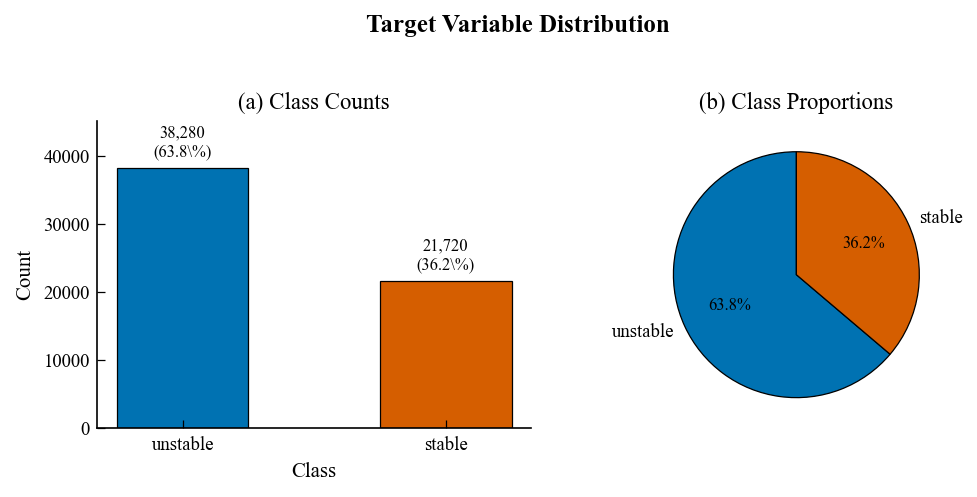

In [4]:
class_counts = df[TARGET].value_counts()
class_pct    = df[TARGET].value_counts(normalize=True) * 100

print("Class distribution:")
for cls in class_counts.index:
    print(f"  {cls}: {class_counts[cls]:,} ({class_pct[cls]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

# (a) Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   width=0.5, color=PALETTE_2, edgecolor='black', linewidth=0.6)
axes[0].set_title('(a) Class Counts')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, class_counts.max() * 1.18)
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + class_counts.max() * 0.03,
                 f'{cnt:,}\n({class_pct[cls]:.1f}\%)',
                 ha='center', fontsize=8, va='bottom')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (b) Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values, labels=class_counts.index,
    autopct='%1.1f%%', startangle=90, colors=PALETTE_2,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.6},
    textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontsize(8)
axes[1].set_title('(b) Class Proportions')

fig.suptitle('Target Variable Distribution', fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_FIGS, 'class_distribution.png'), dpi=FIGURE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_FIGS, 'class_distribution.pdf'), bbox_inches='tight')
plt.show()


## 4. Feature Distributions

Histograms of all 12 input features. Features are grouped by type:
- **tau1–tau4**: reaction times of the four network nodes
- **p1–p4**: nominal power consumed or produced at each node
- **g1–g4**: price elasticity coefficients at each node

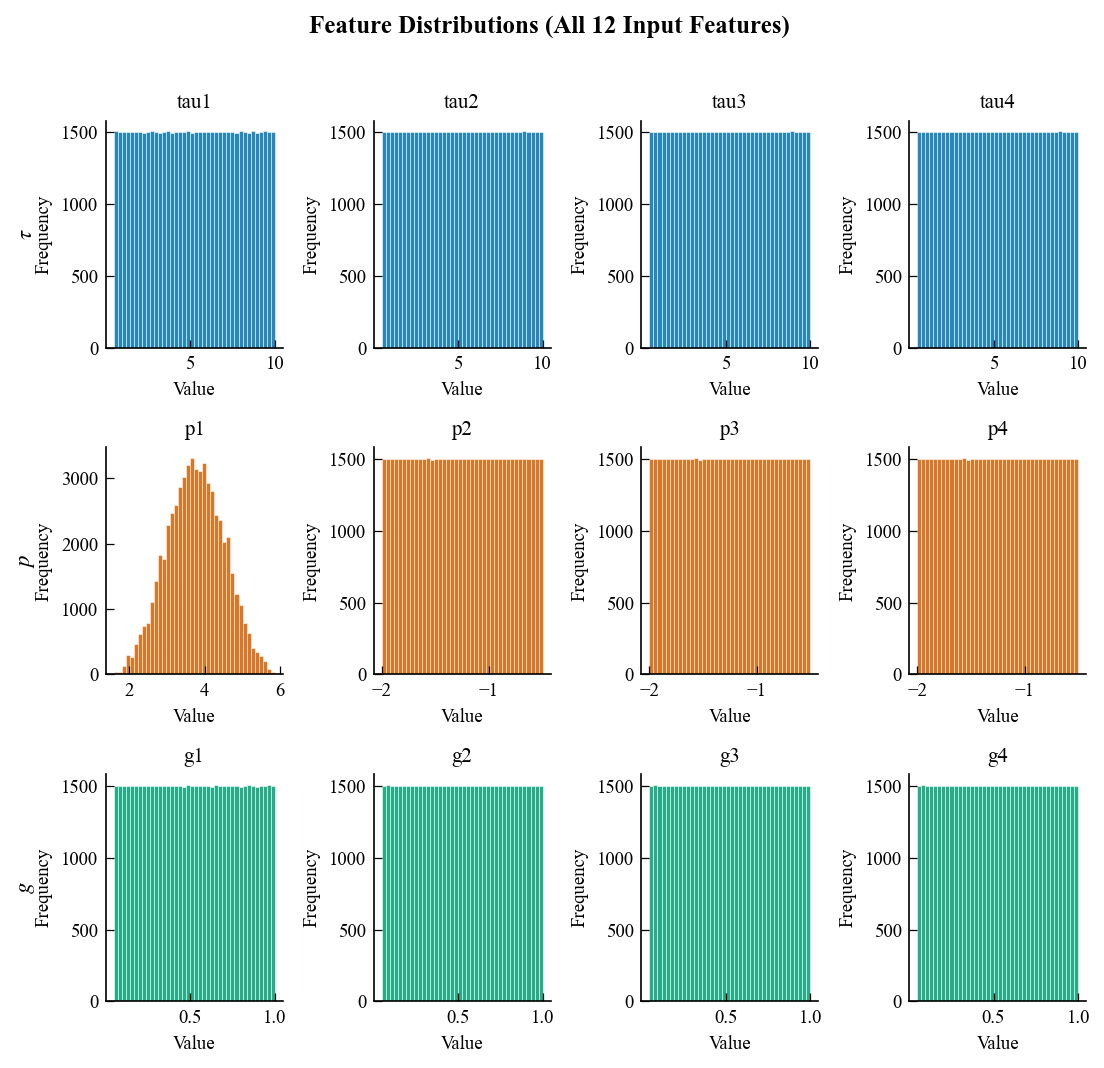

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(7.5, 7))
feature_groups = {
    r'$\tau$': ['tau1', 'tau2', 'tau3', 'tau4'],
    r'$p$'   : ['p1',   'p2',   'p3',   'p4'],
    r'$g$'   : ['g1',   'g2',   'g3',   'g4'],
}
group_colors = {r'$\tau$': CB_BLUE, r'$p$': CB_ORANGE, r'$g$': CB_GREEN}

for row_idx, (group, features) in enumerate(feature_groups.items()):
    for col_idx, feat in enumerate(features):
        ax = axes[row_idx, col_idx]
        ax.hist(df[feat], bins=40, color=group_colors[group],
                edgecolor='white', linewidth=0.3, alpha=0.85)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Row label on leftmost column
        if col_idx == 0:
            ax.annotate(group, xy=(-0.45, 0.5), xycoords='axes fraction',
                        fontsize=11, ha='center', va='center', rotation=90)

fig.suptitle('Feature Distributions (All 12 Input Features)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout(h_pad=1.0, w_pad=0.8)
fig.savefig(os.path.join(RESULTS_FIGS, 'feature_histograms.png'), dpi=FIGURE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_FIGS, 'feature_histograms.pdf'), bbox_inches='tight')
plt.show()


## 5. Feature Distribution by Class

Overlapping histograms showing how each feature separates the two classes.
Features where the two distributions diverge strongly are likely to be informative
for classification.

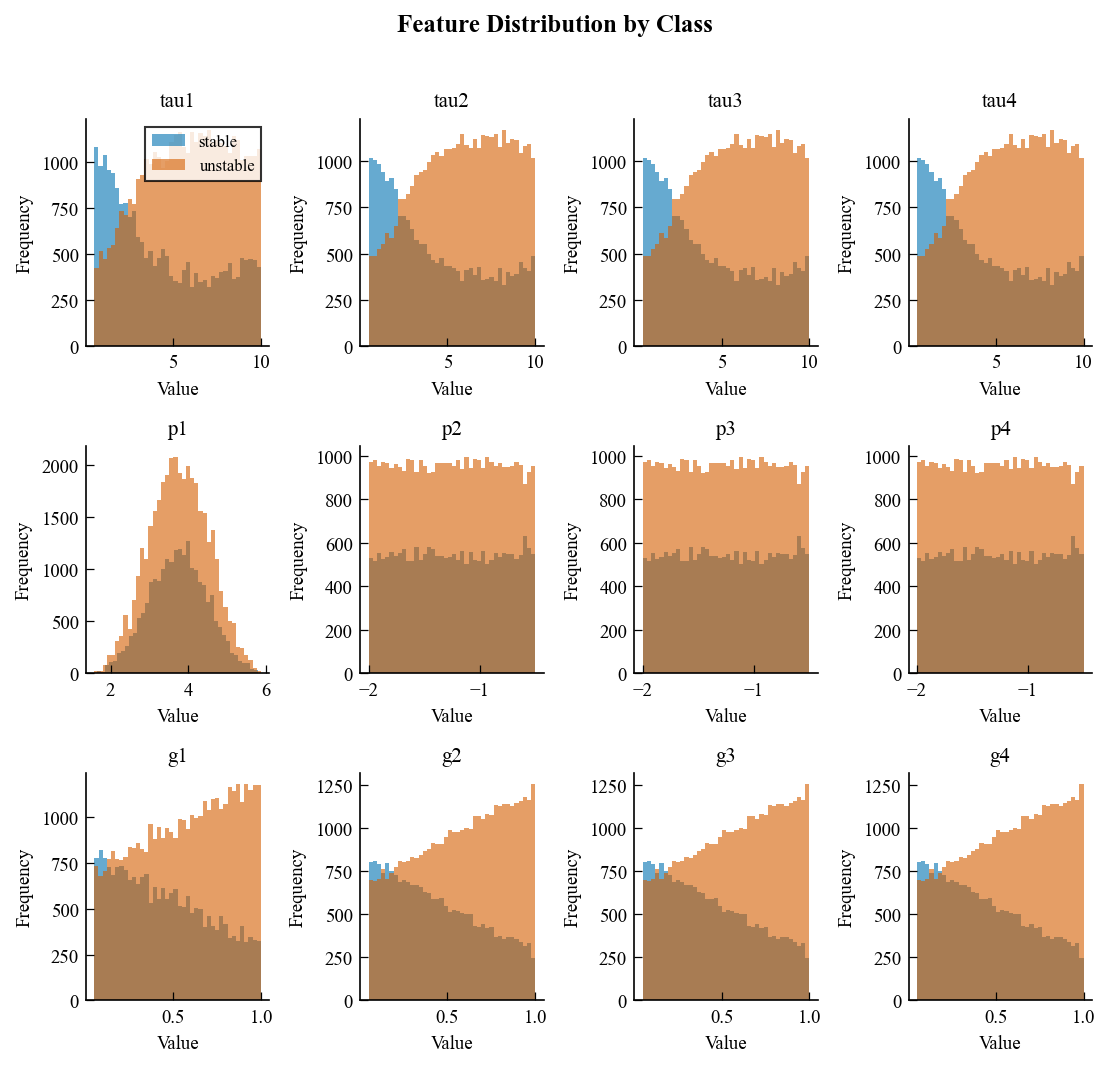

In [6]:
feature_groups_plain = {
    'tau': ['tau1', 'tau2', 'tau3', 'tau4'],
    'p'  : ['p1',   'p2',   'p3',   'p4'],
    'g'  : ['g1',   'g2',   'g3',   'g4'],
}

fig, axes = plt.subplots(3, 4, figsize=(7.5, 7))
for row_idx, (group, features) in enumerate(feature_groups_plain.items()):
    for col_idx, feat in enumerate(features):
        ax = axes[row_idx, col_idx]
        for cls in ['stable', 'unstable']:
            subset = df[df[TARGET] == cls][feat]
            ax.hist(subset, bins=40, alpha=0.6, label=cls,
                    color=CLASS_PALETTE[cls], edgecolor='none')
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx == 0 and col_idx == 0:
            ax.legend(frameon=True, fancybox=False, edgecolor='black',
                      fontsize=8, loc='upper right')

fig.suptitle('Feature Distribution by Class', fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout(h_pad=1.0, w_pad=0.8)
fig.savefig(os.path.join(RESULTS_FIGS, 'feature_distribution_by_class.png'), dpi=FIGURE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_FIGS, 'feature_distribution_by_class.pdf'), bbox_inches='tight')
plt.show()


## 6. Violin Plots by Class

Violin plots combine a box plot with a kernel density estimate. They show the full
distribution shape, median, and interquartile range for each feature across the two
stability classes.

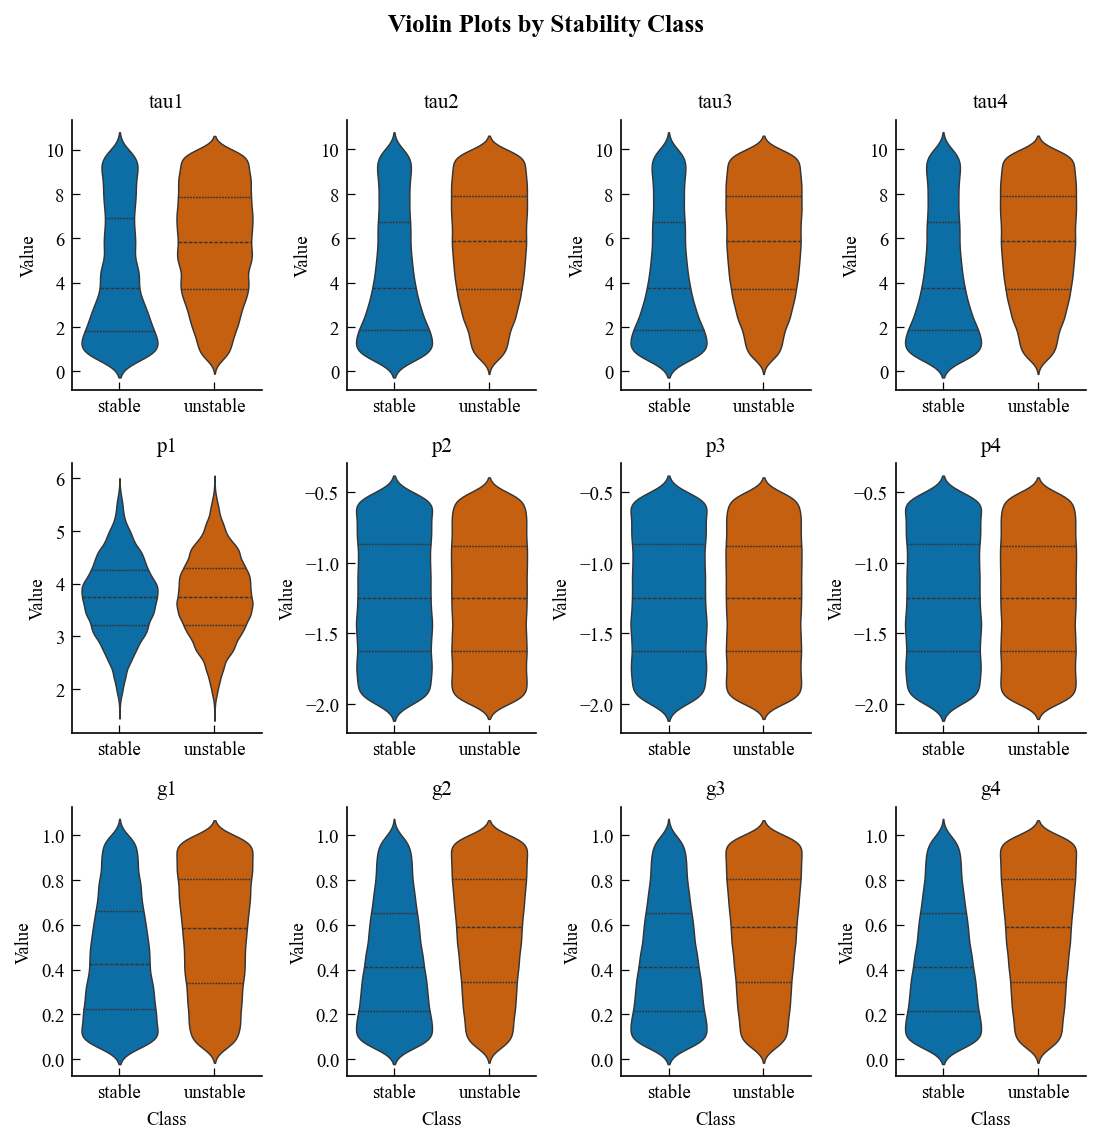

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(7.5, 7.5))
for row_idx, (group, features) in enumerate(feature_groups_plain.items()):
    for col_idx, feat in enumerate(features):
        ax = axes[row_idx, col_idx]
        sns.violinplot(data=df, x=TARGET, y=feat, ax=ax,
                       palette=CLASS_PALETTE, hue=TARGET, legend=False,
                       linewidth=0.7, saturation=0.85, inner='quartile',
                       order=['stable', 'unstable'])
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Value', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    # Only show x-label on the bottom row
    for col_idx in range(4):
        if row_idx == 2:
            axes[row_idx, col_idx].set_xlabel('Class', fontsize=9)

fig.suptitle('Violin Plots by Stability Class', fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout(h_pad=1.0, w_pad=0.8)
fig.savefig(os.path.join(RESULTS_FIGS, 'violin_plots.png'), dpi=FIGURE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_FIGS, 'violin_plots.pdf'), bbox_inches='tight')
plt.show()


## 7. Correlation Matrix

Pearson correlation coefficients between all 12 input features. Pairs with
|r| > 0.95 are candidates for removal in the feature selection step (Notebook 02).

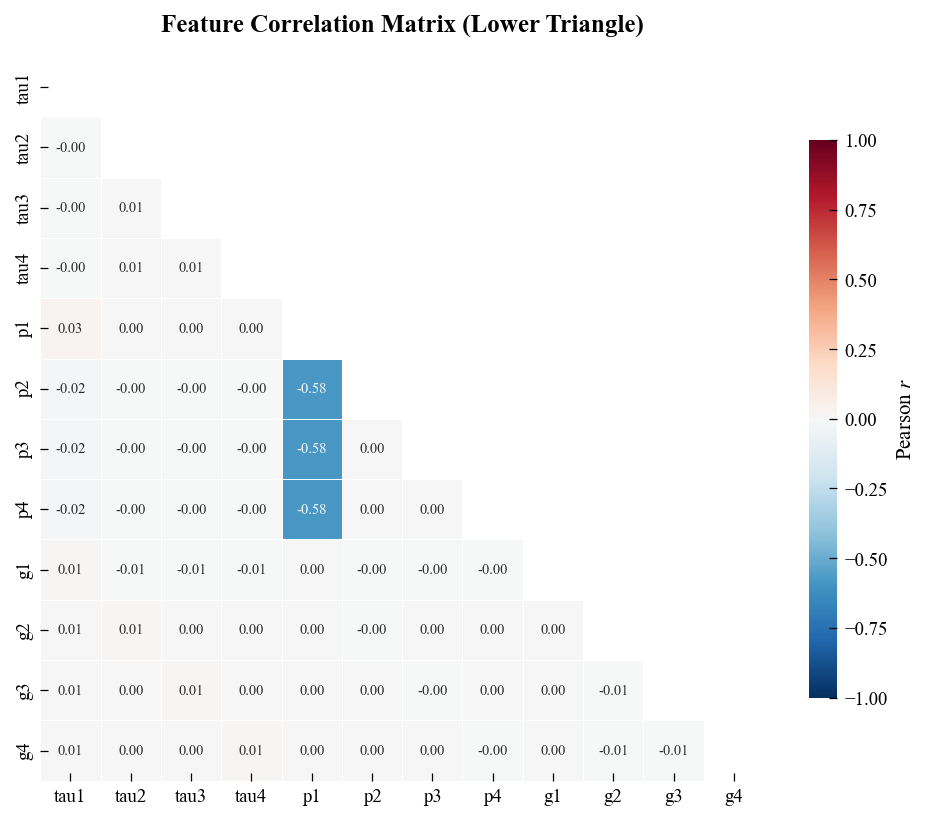

No feature pairs with |r| > 0.95 found.


In [8]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson $r$'},
            mask=mask, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (Lower Triangle)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='both', which='major', labelsize=9)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_FIGS, 'correlation_matrix.png'), dpi=FIGURE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_FIGS, 'correlation_matrix.pdf'), bbox_inches='tight')
plt.show()

# Report high-correlation pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 4)))

if high_corr:
    print("Feature pairs with |r| > 0.95:")
    for a, b, r in high_corr:
        print(f"  {a} — {b}: {r}")
else:
    print("No feature pairs with |r| > 0.95 found.")


## 8. Save Processed Data for Downstream Notebooks

The cleaned dataframe (with `stab` retained but flagged) is saved for use in Notebook 02.
The train/test split is performed in Notebook 02 **before** any feature engineering or
selection, ensuring that no information from the test set influences the feature
transformation pipeline.

In [9]:
out_path = os.path.join(RESULTS_TABLES, 'dataset_verified.csv')
df.to_csv(out_path, index=False)
print(f"Dataset saved to: {out_path}")
print(f"Shape: {df.shape}")
print("Ready for Notebook 02: Feature Engineering and Selection.")


Dataset saved to: ../results/tables\dataset_verified.csv
Shape: (60000, 14)
Ready for Notebook 02: Feature Engineering and Selection.
